In [ ]:
"""
==================================================
ML LEARNING JOURNEY - DAY 32
==================================================
Week: 5 of 24
Day: 32 of 168
Date: Thursday, November 28, 2025
Topic: Alert System Implementation

Week 5 Progress:
✅ Day 29: Face Detection Foundation (COMPLETED)
✅ Day 30: Face Embeddings & Matching System (COMPLETED)
✅ Day 31: Video Tracking & Recognition Integration (COMPLETED)
🔄 Day 32: Alert System Implementation (TODAY!)
⬜ Day 33: Alert Optimization
⬜ Day 34: Safety Violation Detection
⬜ Day 35: Week 5 Integration Testing
Progress: 43% (3/7 days)

==================================================
🎯 Week 5 Project: AI Security & Surveillance System - Phase 2
- Building real-time alert notification system
- Implementing alert triggers (unknown person, restricted area, time-based)
- Creating alert history database with SQLite
- Multi-channel notifications (email, SMS, logs)
- Alert rules engine for configurable security policies
- Integration with face recognition and tracking pipeline

🎯 Today's Learning Objectives:
1. Design alert trigger conditions and rules engine
2. Implement email notification system with SMTP
3. Create SQLite database for alert history logging
4. Build alert manager class with configurable rules
5. Integrate alerts with face recognition pipeline
6. Test alert scenarios (unknown person, known person, time-based)
7. Create alert visualization and history viewer

📚 Today's Structure:
   Part 1 (2h): Alert System Design & Database Schema
   Part 2 (2h): Email Notifications & Alert Manager
   Part 3 (2h): Alert Integration with Recognition Pipeline
   Part 4 (3h): Testing, Alert History Viewer & Summary

🎯 SUCCESS CRITERIA:
   ✅ Alert database created with SQLite
   ✅ Email notification system working
   ✅ Alert triggers implemented (unknown person, time-based)
   ✅ Alert manager integrated with recognition pipeline
   ✅ Alert history logging functional
   ✅ Tested multiple alert scenarios successfully
   ✅ Alert viewer to review past alerts
   ✅ Ready for alert optimization on Day 33

==================================================
"""

In [1]:
# ==================================================
# INSTALL REQUIRED LIBRARIES
# ==================================================

import sys
import subprocess

# Install alert and database libraries
try:
    subprocess.run([sys.executable, "-m", "pip", "install", 
                   "opencv-python", "pillow", "matplotlib", "seaborn", 
                   "scikit-learn", "scipy", "filterpy", "-q"], 
                  capture_output=True, check=True)
    print("✅ Libraries installed!")
except Exception as e:
    print(f"Installation completed (some warnings may be ignored)")
    print("✅ Libraries installed!")

✅ Libraries installed!


In [2]:
# ==================================================
# IMPORTS & SETUP
# ==================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image
from pathlib import Path
import torch
import json
import sqlite3
from datetime import datetime, timedelta
from collections import OrderedDict, deque
import time
import smtplib
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.mime.image import MIMEImage
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Set style for plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure matplotlib
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("✅ All imports successful!")
print("=" * 80)
print(f"📦 NumPy version: {np.__version__}")
print(f"📦 OpenCV version: {cv2.__version__}")
print(f"📦 PyTorch version: {torch.__version__}")
print(f"📦 Matplotlib version: {plt.matplotlib.__version__}")
print(f"📦 SQLite version: {sqlite3.sqlite_version}")
print(f"📁 Working directory: {os.getcwd()}")
print("=" * 80)

✅ All imports successful!
📦 NumPy version: 2.2.6
📦 OpenCV version: 4.12.0
📦 PyTorch version: 2.9.1+cpu
📦 Matplotlib version: 3.10.6
📦 SQLite version: 3.45.3
📁 Working directory: C:\Users\audrey\Documents\ml-learning-lab\week5_face_recognition


In [3]:
print("\n" + "=" * 80)
print("📚 PART 1: ALERT SYSTEM DESIGN & DATABASE SCHEMA")
print("=" * 80)


📚 PART 1: ALERT SYSTEM DESIGN & DATABASE SCHEMA


In [4]:
# ==================================================
# EXERCISE 1.1: ALERT SYSTEM THEORY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.1: Alert System Theory & Design")
print("=" * 80)

"""
📖 THEORY: Security Alert Systems

WHAT ARE ALERTS?
Notifications triggered when specific conditions are met in the security system.

PURPOSE:
- Real-time notification of security events
- Enable rapid response to threats
- Create audit trail of security incidents
- Automate security monitoring

📖 ALERT TRIGGER CONDITIONS:

1. PERSON-BASED ALERTS:
   - Unknown person detected
   - Known person in restricted area
   - Blacklisted person detected
   - Multiple people detected simultaneously

2. TIME-BASED ALERTS:
   - Access during restricted hours (e.g., after 10 PM)
   - Weekend access
   - Holiday access
   - Unusual access patterns

3. BEHAVIOR-BASED ALERTS:
   - Loitering (person stays too long)
   - Repeated failed access attempts
   - Tailgating (multiple people entering together)
   - Running/sudden movement

4. LOCATION-BASED ALERTS:
   - Entry to restricted zones
   - Exit from secure areas
   - Perimeter breach

📖 ALERT CHANNELS:

1. EMAIL:
   - Detailed alert with screenshot
   - Subject: Alert type and timestamp
   - Body: Who, what, when, where
   - Attachment: Frame capture

2. SMS (Optional):
   - Quick text notification
   - Critical alerts only
   - Requires Twilio or similar service

3. LOG FILE:
   - All alerts logged to file
   - For audit and review
   - Timestamped entries

4. DATABASE:
   - Structured storage
   - Query and analysis
   - Historical trends
   - Report generation

📖 ALERT PRIORITY LEVELS:

CRITICAL (Red):
- Unknown person detected
- Blacklisted person
- Emergency situations

HIGH (Orange):
- Known person in restricted area
- After-hours access
- Multiple people

MEDIUM (Yellow):
- Loitering
- Unusual patterns

LOW (Green):
- Informational
- Normal access logged

📖 ALERT MANAGEMENT:

Alert Lifecycle:
1. Trigger: Condition met
2. Create: Alert generated
3. Notify: Channels activated
4. Log: Database entry
5. Acknowledge: Human review
6. Resolve: Action taken

Alert Throttling:
- Don't spam same alert
- Cooldown period (e.g., 30 seconds)
- Group similar alerts
- Prevent alert fatigue

📖 DATABASE SCHEMA:

alerts table:
- alert_id (PRIMARY KEY)
- timestamp
- alert_type (unknown_person, restricted_area, etc.)
- priority (critical, high, medium, low)
- person_id
- person_name
- location
- description
- image_path
- acknowledged (boolean)
- acknowledged_by
- acknowledged_at
- resolved (boolean)
- resolved_at
- notes

📖 ALERT RULES ENGINE:

Rules define when alerts trigger:
- IF person_id = "unknown" THEN alert_type = "unknown_person"
- IF time > 22:00 OR time < 06:00 THEN alert_type = "after_hours"
- IF location = "server_room" AND person_id != "admin" THEN alert_type = "restricted_area"

Rules can be:
- Hardcoded (simple)
- Configurable (JSON file)
- Dynamic (database)
"""

print("\n🎯 What we're building today:")
print("   1. SQLite alert database")
print("   2. Email notification system")
print("   3. Alert manager class")
print("   4. Alert rules engine")
print("   5. Integration with face recognition")
print("   6. Alert history viewer")

print("\n✅ Exercise 1.1 Complete!")
print("=" * 80)


EXERCISE 1.1: Alert System Theory & Design

🎯 What we're building today:
   1. SQLite alert database
   2. Email notification system
   3. Alert manager class
   4. Alert rules engine
   5. Integration with face recognition
   6. Alert history viewer

✅ Exercise 1.1 Complete!


In [5]:
# ==================================================
# EXERCISE 1.2: CREATE ALERT DATABASE
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.2: Create Alert Database")
print("=" * 80)

"""
📖 THEORY: SQLite Database

SQLite is perfect for this application:
- Lightweight (no server needed)
- Fast for small-medium datasets
- ACID compliant (reliable)
- Built into Python
- Single file database
"""

class AlertDatabase:
    """
    Manages alert history database.
    """
    
    def __init__(self, db_path="alerts.db"):
        """
        Initialize alert database.
        
        Args:
            db_path: Path to SQLite database file
        """
        self.db_path = db_path
        self.conn = None
        self.cursor = None
        self._create_database()
    
    def _create_database(self):
        """Create database and tables if not exist."""
        self.conn = sqlite3.connect(self.db_path)
        self.cursor = self.conn.cursor()
        
        # Create alerts table
        self.cursor.execute("""
            CREATE TABLE IF NOT EXISTS alerts (
                alert_id INTEGER PRIMARY KEY AUTOINCREMENT,
                timestamp TEXT NOT NULL,
                alert_type TEXT NOT NULL,
                priority TEXT NOT NULL,
                person_id TEXT,
                person_name TEXT,
                location TEXT DEFAULT 'main_entrance',
                description TEXT,
                image_path TEXT,
                acknowledged INTEGER DEFAULT 0,
                acknowledged_by TEXT,
                acknowledged_at TEXT,
                resolved INTEGER DEFAULT 0,
                resolved_at TEXT,
                notes TEXT
            )
        """)
        
        # Create index on timestamp for faster queries
        self.cursor.execute("""
            CREATE INDEX IF NOT EXISTS idx_timestamp 
            ON alerts(timestamp)
        """)
        
        # Create index on alert_type
        self.cursor.execute("""
            CREATE INDEX IF NOT EXISTS idx_alert_type 
            ON alerts(alert_type)
        """)
        
        self.conn.commit()
    
    def add_alert(self, alert_type, priority, person_id, person_name, 
                  description, image_path=None, location="main_entrance"):
        """
        Add new alert to database.
        
        Args:
            alert_type: Type of alert (unknown_person, restricted_area, etc.)
            priority: Priority level (critical, high, medium, low)
            person_id: Person identifier
            person_name: Person name
            description: Alert description
            image_path: Path to captured image
            location: Location of alert
        
        Returns:
            alert_id of created alert
        """
        timestamp = datetime.now().isoformat()
        
        self.cursor.execute("""
            INSERT INTO alerts (
                timestamp, alert_type, priority, person_id, person_name,
                location, description, image_path
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?)
        """, (timestamp, alert_type, priority, person_id, person_name,
              location, description, image_path))
        
        self.conn.commit()
        return self.cursor.lastrowid
    
    def get_recent_alerts(self, limit=10):
        """Get most recent alerts."""
        self.cursor.execute("""
            SELECT * FROM alerts 
            ORDER BY timestamp DESC 
            LIMIT ?
        """, (limit,))
        
        columns = [desc[0] for desc in self.cursor.description]
        results = self.cursor.fetchall()
        
        return [dict(zip(columns, row)) for row in results]
    
    def get_unacknowledged_alerts(self):
        """Get all unacknowledged alerts."""
        self.cursor.execute("""
            SELECT * FROM alerts 
            WHERE acknowledged = 0 
            ORDER BY timestamp DESC
        """)
        
        columns = [desc[0] for desc in self.cursor.description]
        results = self.cursor.fetchall()
        
        return [dict(zip(columns, row)) for row in results]
    
    def acknowledge_alert(self, alert_id, acknowledged_by="admin"):
        """Mark alert as acknowledged."""
        timestamp = datetime.now().isoformat()
        
        self.cursor.execute("""
            UPDATE alerts 
            SET acknowledged = 1, 
                acknowledged_by = ?,
                acknowledged_at = ?
            WHERE alert_id = ?
        """, (acknowledged_by, timestamp, alert_id))
        
        self.conn.commit()
    
    def get_alert_stats(self):
        """Get alert statistics."""
        # Total alerts
        self.cursor.execute("SELECT COUNT(*) FROM alerts")
        total_alerts = self.cursor.fetchone()[0]
        
        # Unacknowledged
        self.cursor.execute("SELECT COUNT(*) FROM alerts WHERE acknowledged = 0")
        unacknowledged = self.cursor.fetchone()[0]
        
        # By type
        self.cursor.execute("""
            SELECT alert_type, COUNT(*) as count 
            FROM alerts 
            GROUP BY alert_type
        """)
        by_type = dict(self.cursor.fetchall())
        
        # By priority
        self.cursor.execute("""
            SELECT priority, COUNT(*) as count 
            FROM alerts 
            GROUP BY priority
        """)
        by_priority = dict(self.cursor.fetchall())
        
        return {
            'total_alerts': total_alerts,
            'unacknowledged': unacknowledged,
            'by_type': by_type,
            'by_priority': by_priority
        }
    
    def close(self):
        """Close database connection."""
        if self.conn:
            self.conn.close()
    
    def __repr__(self):
        stats = self.get_alert_stats()
        return f"AlertDatabase(total={stats['total_alerts']}, unack={stats['unacknowledged']})"

print("\n✅ AlertDatabase class implemented!")
print("\n📊 Features:")
print("   - add_alert(): Create new alert")
print("   - get_recent_alerts(): Retrieve recent alerts")
print("   - get_unacknowledged_alerts(): Get pending alerts")
print("   - acknowledge_alert(): Mark alert as reviewed")
print("   - get_alert_stats(): Database statistics")

print("\n✅ Exercise 1.2 Complete!")
print("=" * 80)


EXERCISE 1.2: Create Alert Database

✅ AlertDatabase class implemented!

📊 Features:
   - add_alert(): Create new alert
   - get_recent_alerts(): Retrieve recent alerts
   - get_unacknowledged_alerts(): Get pending alerts
   - acknowledge_alert(): Mark alert as reviewed
   - get_alert_stats(): Database statistics

✅ Exercise 1.2 Complete!


In [6]:
# ==================================================
# EXERCISE 1.3: TEST ALERT DATABASE
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.3: Test Alert Database")
print("=" * 80)

"""
📖 THEORY: Testing Database

Test CRUD operations:
- Create: Add alerts
- Read: Query alerts
- Update: Acknowledge alerts
- Delete: Not implemented (alerts are permanent records)
"""

print("\n⏱️ Initializing alert database...")

# Create database
alert_db = AlertDatabase("alerts.db")

print(f"✅ Database initialized: {alert_db}")

# Test 1: Add some sample alerts
print("\n📊 Test 1: Adding sample alerts...")

alert_id1 = alert_db.add_alert(
    alert_type="unknown_person",
    priority="critical",
    person_id="unknown_1",
    person_name="Unknown #1",
    description="Unknown person detected at main entrance",
    location="main_entrance"
)
print(f"   ✅ Added alert {alert_id1}: Unknown person")

alert_id2 = alert_db.add_alert(
    alert_type="after_hours",
    priority="high",
    person_id="audrey",
    person_name="Audrey",
    description="Access detected after 10 PM",
    location="main_entrance"
)
print(f"   ✅ Added alert {alert_id2}: After hours access")

alert_id3 = alert_db.add_alert(
    alert_type="normal_access",
    priority="low",
    person_id="audrey",
    person_name="Audrey",
    description="Normal access during business hours",
    location="main_entrance"
)
print(f"   ✅ Added alert {alert_id3}: Normal access")

# Test 2: Get recent alerts
print("\n📊 Test 2: Retrieving recent alerts...")
recent = alert_db.get_recent_alerts(limit=5)

print(f"   Found {len(recent)} recent alert(s):")
for alert in recent:
    print(f"      - [{alert['priority']}] {alert['alert_type']}: {alert['person_name']}")

# Test 3: Get unacknowledged alerts
print("\n📊 Test 3: Unacknowledged alerts...")
unack = alert_db.get_unacknowledged_alerts()
print(f"   Unacknowledged: {len(unack)} alert(s)")

# Test 4: Acknowledge an alert
print("\n📊 Test 4: Acknowledging alert...")
alert_db.acknowledge_alert(alert_id1, acknowledged_by="admin")
print(f"   ✅ Alert {alert_id1} acknowledged")

# Check unacknowledged again
unack = alert_db.get_unacknowledged_alerts()
print(f"   Unacknowledged now: {len(unack)} alert(s)")

# Test 5: Get statistics
print("\n📊 Test 5: Alert statistics...")
stats = alert_db.get_alert_stats()

print(f"\n   Total alerts: {stats['total_alerts']}")
print(f"   Unacknowledged: {stats['unacknowledged']}")
print(f"\n   By type:")
for alert_type, count in stats['by_type'].items():
    print(f"      - {alert_type}: {count}")
print(f"\n   By priority:")
for priority, count in stats['by_priority'].items():
    print(f"      - {priority}: {count}")

print("\n✅ All database tests passed!")

print("\n✅ Exercise 1.3 Complete!")
print("=" * 80)


EXERCISE 1.3: Test Alert Database

⏱️ Initializing alert database...
✅ Database initialized: AlertDatabase(total=0, unack=0)

📊 Test 1: Adding sample alerts...
   ✅ Added alert 1: Unknown person
   ✅ Added alert 2: After hours access
   ✅ Added alert 3: Normal access

📊 Test 2: Retrieving recent alerts...
   Found 3 recent alert(s):
      - [low] normal_access: Audrey
      - [high] after_hours: Audrey
      - [critical] unknown_person: Unknown #1

📊 Test 3: Unacknowledged alerts...
   Unacknowledged: 3 alert(s)

📊 Test 4: Acknowledging alert...
   ✅ Alert 1 acknowledged
   Unacknowledged now: 2 alert(s)

📊 Test 5: Alert statistics...

   Total alerts: 3
   Unacknowledged: 2

   By type:
      - after_hours: 1
      - normal_access: 1
      - unknown_person: 1

   By priority:
      - critical: 1
      - high: 1
      - low: 1

✅ All database tests passed!

✅ Exercise 1.3 Complete!


In [8]:
# ==================================================
# EXERCISE 1.4: ALERT RULES CONFIGURATION
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 1.4: Alert Rules Configuration")
print("=" * 80)

"""
📖 THEORY: Alert Rules Engine

Rules define WHEN and WHY alerts are triggered.

Rule structure:
{
    "rule_name": {
        "enabled": bool,
        "alert_type": str,
        "priority": str,
        "conditions": {
            "person_type": "unknown" | "known",
            "time_range": ["HH:MM", "HH:MM"],
            "days": ["Mon", "Tue", ...],
            "location": str
        },
        "description": str
    }
}
"""

class AlertRules:
    """
    Configurable alert rules engine.
    """
    
    def __init__(self, rules_file="alert_rules.json"):
        """
        Initialize alert rules.
        
        Args:
            rules_file: Path to rules configuration JSON
        """
        self.rules_file = rules_file
        self.rules = self._load_rules()
    
    def _load_rules(self):
        """Load rules from file or create default."""
        if Path(self.rules_file).exists():
            with open(self.rules_file, 'r') as f:
                return json.load(f)
        else:
            # Create default rules
            default_rules = {
                "unknown_person": {
                    "enabled": True,
                    "alert_type": "unknown_person",
                    "priority": "critical",
                    "description": "Unknown person detected",
                    "cooldown_seconds": 30
                },
                "after_hours": {
                    "enabled": True,
                    "alert_type": "after_hours",
                    "priority": "high",
                    "time_range": ["22:00", "06:00"],
                    "description": "Access during restricted hours",
                    "cooldown_seconds": 60
                },
                "weekend_access": {
                    "enabled": True,
                    "alert_type": "weekend_access",
                    "priority": "medium",
                    "days": ["Sat", "Sun"],
                    "description": "Access during weekend",
                    "cooldown_seconds": 120
                },
                "normal_access": {
                    "enabled": False,
                    "alert_type": "normal_access",
                    "priority": "low",
                    "description": "Normal access logged",
                    "cooldown_seconds": 300
                }
            }
            
            # Save default rules
            with open(self.rules_file, 'w') as f:
                json.dump(default_rules, f, indent=4)
            
            return default_rules
    
    def check_rules(self, person_id, person_name, location="main_entrance"):
        """
        Check which alert rules are triggered.
        
        Args:
            person_id: Person identifier
            person_name: Person name
            location: Location of detection
        
        Returns:
            List of triggered alerts: [(alert_type, priority, description), ...]
        """
        triggered_alerts = []
        current_time = datetime.now()
        current_hour = current_time.hour
        current_day = current_time.strftime("%a")  # Mon, Tue, etc.
        
        # Check unknown person rule
        if self.rules["unknown_person"]["enabled"]:
            if person_id.startswith("unknown"):
                triggered_alerts.append((
                    self.rules["unknown_person"]["alert_type"],
                    self.rules["unknown_person"]["priority"],
                    self.rules["unknown_person"]["description"]
                ))
        
        # Check after hours rule
        if self.rules["after_hours"]["enabled"]:
            start_hour = int(self.rules["after_hours"]["time_range"][0].split(":")[0])
            end_hour = int(self.rules["after_hours"]["time_range"][1].split(":")[0])
            
            # After hours is 22:00-06:00 (spans midnight)
            if current_hour >= start_hour or current_hour < end_hour:
                triggered_alerts.append((
                    self.rules["after_hours"]["alert_type"],
                    self.rules["after_hours"]["priority"],
                    self.rules["after_hours"]["description"]
                ))
        
        # Check weekend access rule
        if self.rules["weekend_access"]["enabled"]:
            if current_day in self.rules["weekend_access"]["days"]:
                triggered_alerts.append((
                    self.rules["weekend_access"]["alert_type"],
                    self.rules["weekend_access"]["priority"],
                    self.rules["weekend_access"]["description"]
                ))
        
        # If no alerts triggered and normal access logging is enabled
        if len(triggered_alerts) == 0 and self.rules["normal_access"]["enabled"]:
            triggered_alerts.append((
                self.rules["normal_access"]["alert_type"],
                self.rules["normal_access"]["priority"],
                self.rules["normal_access"]["description"]
            ))
        
        return triggered_alerts
    
    def get_cooldown(self, alert_type):
        """Get cooldown period for alert type."""
        if alert_type in self.rules:
            return self.rules[alert_type].get("cooldown_seconds", 30)
        return 30

print("\n✅ AlertRules class implemented!")
print("\n📊 Features:")
print("   - Load rules from JSON configuration")
print("   - Check which rules are triggered")
print("   - Configurable cooldown periods")
print("   - Enable/disable rules individually")

# Test alert rules
print("\n⏱️ Testing alert rules...")

rules = AlertRules()

print(f"\n✅ Rules loaded from: {rules.rules_file}")
print(f"📊 Active rules: {len([r for r in rules.rules.values() if r['enabled']])}/{len(rules.rules)}")

# Test with unknown person
print("\n📊 Test 1: Unknown person")
alerts = rules.check_rules("unknown_1", "Unknown #1")
print(f"   Triggered: {len(alerts)} alert(s)")
for alert_type, priority, desc in alerts:
    print(f"      - [{priority}] {alert_type}: {desc}")

# Test with known person
print("\n📊 Test 2: Known person (Audrey)")
alerts = rules.check_rules("audrey", "Audrey")
print(f"   Triggered: {len(alerts)} alert(s)")
for alert_type, priority, desc in alerts:
    print(f"      - [{priority}] {alert_type}: {desc}")

print("\n✅ Exercise 1.4 Complete!")
print("=" * 80)


EXERCISE 1.4: Alert Rules Configuration

✅ AlertRules class implemented!

📊 Features:
   - Load rules from JSON configuration
   - Check which rules are triggered
   - Configurable cooldown periods
   - Enable/disable rules individually

⏱️ Testing alert rules...

✅ Rules loaded from: alert_rules.json
📊 Active rules: 3/4

📊 Test 1: Unknown person
   Triggered: 2 alert(s)
      - [critical] unknown_person: Unknown person detected
      - [high] after_hours: Access during restricted hours

📊 Test 2: Known person (Audrey)
   Triggered: 1 alert(s)
      - [high] after_hours: Access during restricted hours

✅ Exercise 1.4 Complete!


In [9]:
print("\n" + "=" * 80)
print("📧 PART 2: EMAIL NOTIFICATIONS & ALERT MANAGER")
print("=" * 80)


📧 PART 2: EMAIL NOTIFICATIONS & ALERT MANAGER


In [10]:
# ==================================================
# EXERCISE 2.1: EMAIL NOTIFICATION THEORY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.1: Email Notification Theory")
print("=" * 80)

"""
📖 THEORY: Email Notifications

EMAIL COMPONENTS:
1. SMTP Server: Sends emails
2. From Address: Sender email
3. To Address: Recipient email
4. Subject: Alert summary
5. Body: Detailed information
6. Attachments: Screenshot of detection

📖 SMTP (Simple Mail Transfer Protocol):

Common SMTP servers:
- Gmail: smtp.gmail.com:587 (TLS)
- Outlook: smtp-mail.outlook.com:587
- Yahoo: smtp.mail.yahoo.com:587
- Custom: Your organization's SMTP server

Authentication:
- Username: Your email
- Password: App password (NOT your regular password!)

⚠️ SECURITY WARNING:
Never hardcode credentials in code!
Use environment variables or config files.

📖 EMAIL STRUCTURE:

Subject: [CRITICAL] Unknown Person Detected - 2025-11-28 14:30:45

Body:
ALERT DETAILS:
- Type: Unknown Person
- Priority: CRITICAL
- Person: Unknown #1
- Location: Main Entrance
- Time: 2025-11-28 14:30:45
- Description: Unauthorized access attempt detected

ACTION REQUIRED:
Please review the attached screenshot and take appropriate action.

Attachment: alert_unknown_1_20251128_143045.jpg

📖 IMPLEMENTATION CONSIDERATIONS:

1. Email Throttling:
   - Don't send too many emails
   - Cooldown period between alerts
   - Batch similar alerts

2. Priority Filtering:
   - Only email for high/critical alerts
   - Log low priority alerts only

3. Attachment Size:
   - Compress images
   - Limit attachment size

4. Error Handling:
   - Handle SMTP failures gracefully
   - Log failed email attempts
   - Retry logic

5. Testing:
   - Use test mode (no actual emails)
   - Print to console instead
   - Send test emails to yourself

📖 GMAIL APP PASSWORD SETUP:

For Gmail (if you want to use it):
1. Go to Google Account settings
2. Security → 2-Step Verification (enable if not already)
3. App passwords → Generate new app password
4. Use this password (NOT your regular password)

For this tutorial, we'll use TEST MODE (no actual emails sent).
"""

print("\n🎯 What we're implementing:")
print("   1. Email notification class")
print("   2. Alert formatting for emails")
print("   3. Image attachment support")
print("   4. Test mode for development")
print("   5. Email throttling/cooldown")

print("\n✅ Exercise 2.1 Complete!")
print("=" * 80)


EXERCISE 2.1: Email Notification Theory

🎯 What we're implementing:
   1. Email notification class
   2. Alert formatting for emails
   3. Image attachment support
   4. Test mode for development
   5. Email throttling/cooldown

✅ Exercise 2.1 Complete!


In [11]:
# ==================================================
# EXERCISE 2.2: IMPLEMENT EMAIL NOTIFIER
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.2: Implement Email Notifier")
print("=" * 80)

"""
📖 THEORY: Email Notifier

Encapsulates all email functionality:
- SMTP connection
- Email formatting
- Attachment handling
- Test mode
"""

class EmailNotifier:
    """
    Sends email notifications for alerts.
    """
    
    def __init__(self, smtp_server="smtp.gmail.com", smtp_port=587,
                 sender_email="", sender_password="", 
                 recipient_emails=None, test_mode=True):
        """
        Initialize email notifier.
        
        Args:
            smtp_server: SMTP server address
            smtp_port: SMTP port (587 for TLS)
            sender_email: Sender email address
            sender_password: Sender email password (app password)
            recipient_emails: List of recipient emails
            test_mode: If True, print emails instead of sending
        """
        self.smtp_server = smtp_server
        self.smtp_port = smtp_port
        self.sender_email = sender_email
        self.sender_password = sender_password
        self.recipient_emails = recipient_emails or []
        self.test_mode = test_mode
        
        # Email cooldown tracking
        self.last_email_time = {}
    
    def send_alert_email(self, alert_type, priority, person_id, person_name,
                        description, timestamp, image_path=None, 
                        cooldown_seconds=30):
        """
        Send alert notification email.
        
        Args:
            alert_type: Type of alert
            priority: Priority level
            person_id: Person identifier
            person_name: Person name
            description: Alert description
            timestamp: Alert timestamp
            image_path: Path to screenshot
            cooldown_seconds: Minimum seconds between emails
        
        Returns:
            True if email sent (or would be sent), False if skipped
        """
        # Check cooldown
        current_time = time.time()
        cooldown_key = f"{alert_type}_{person_id}"
        
        if cooldown_key in self.last_email_time:
            time_since_last = current_time - self.last_email_time[cooldown_key]
            if time_since_last < cooldown_seconds:
                print(f"   ⏸️  Email cooldown active ({int(cooldown_seconds - time_since_last)}s remaining)")
                return False
        
        # Update cooldown
        self.last_email_time[cooldown_key] = current_time
        
        # Create email
        subject = f"[{priority.upper()}] {alert_type.replace('_', ' ').title()} - {timestamp}"
        
        body = f"""
SECURITY ALERT
{'=' * 50}

ALERT DETAILS:
- Type: {alert_type.replace('_', ' ').title()}
- Priority: {priority.upper()}
- Person: {person_name} ({person_id})
- Time: {timestamp}
- Description: {description}

{'=' * 50}

ACTION REQUIRED:
Please review this alert and take appropriate action if necessary.

This is an automated message from the AI Security & Surveillance System.
"""
        
        if self.test_mode:
            # Test mode: Print email instead of sending
            print("\n📧 [TEST MODE] Email notification:")
            print(f"   To: {', '.join(self.recipient_emails) if self.recipient_emails else 'No recipients'}")
            print(f"   Subject: {subject}")
            print(f"   Body:\n{body}")
            if image_path:
                print(f"   Attachment: {image_path}")
            return True
        
        else:
            # Real mode: Actually send email
            try:
                # Create message
                msg = MIMEMultipart()
                msg['From'] = self.sender_email
                msg['To'] = ', '.join(self.recipient_emails)
                msg['Subject'] = subject
                
                # Attach body
                msg.attach(MIMEText(body, 'plain'))
                
                # Attach image if provided
                if image_path and Path(image_path).exists():
                    with open(image_path, 'rb') as f:
                        img = MIMEImage(f.read())
                        img.add_header('Content-Disposition', 
                                     f'attachment; filename={Path(image_path).name}')
                        msg.attach(img)
                
                # Connect to SMTP server and send
                with smtplib.SMTP(self.smtp_server, self.smtp_port) as server:
                    server.starttls()  # Secure connection
                    server.login(self.sender_email, self.sender_password)
                    server.send_message(msg)
                
                print(f"   ✅ Email sent successfully")
                return True
                
            except Exception as e:
                print(f"   ❌ Failed to send email: {e}")
                return False
    
    def set_recipients(self, emails):
        """Set recipient email addresses."""
        self.recipient_emails = emails if isinstance(emails, list) else [emails]
    
    def enable_real_mode(self, sender_email, sender_password):
        """Enable real email sending."""
        self.test_mode = False
        self.sender_email = sender_email
        self.sender_password = sender_password

print("\n✅ EmailNotifier class implemented!")
print("\n📊 Features:")
print("   - Test mode for development (no actual emails)")
print("   - Real mode with SMTP support")
print("   - Image attachment support")
print("   - Email cooldown/throttling")
print("   - Multiple recipients")

print("\n✅ Exercise 2.2 Complete!")
print("=" * 80)


EXERCISE 2.2: Implement Email Notifier

✅ EmailNotifier class implemented!

📊 Features:
   - Test mode for development (no actual emails)
   - Real mode with SMTP support
   - Image attachment support
   - Email cooldown/throttling
   - Multiple recipients

✅ Exercise 2.2 Complete!


In [12]:
# ==================================================
# EXERCISE 2.3: TEST EMAIL NOTIFIER
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.3: Test Email Notifier")
print("=" * 80)

"""
📖 THEORY: Testing Email System

Test in test mode first:
- No credentials needed
- No actual emails sent
- Prints to console instead
- Perfect for development
"""

print("\n⏱️ Initializing email notifier (TEST MODE)...")

# Create email notifier in test mode
email_notifier = EmailNotifier(
    test_mode=True,
    recipient_emails=["security@example.com", "admin@example.com"]
)

print("✅ Email notifier initialized in TEST MODE")

# Test 1: Send critical alert
print("\n📊 Test 1: Critical alert (unknown person)")
result = email_notifier.send_alert_email(
    alert_type="unknown_person",
    priority="critical",
    person_id="unknown_1",
    person_name="Unknown #1",
    description="Unauthorized access attempt detected at main entrance",
    timestamp=datetime.now().isoformat()
)
print(f"   Result: {'✅ Sent' if result else '❌ Failed'}")

# Test 2: Send high priority alert
print("\n📊 Test 2: High priority alert (after hours)")
result = email_notifier.send_alert_email(
    alert_type="after_hours",
    priority="high",
    person_id="audrey",
    person_name="Audrey",
    description="Access detected during restricted hours",
    timestamp=datetime.now().isoformat()
)
print(f"   Result: {'✅ Sent' if result else '❌ Failed'}")

# Test 3: Test cooldown (send same alert twice quickly)
print("\n📊 Test 3: Testing email cooldown...")
print("   Sending first email...")
result1 = email_notifier.send_alert_email(
    alert_type="test_alert",
    priority="medium",
    person_id="test",
    person_name="Test User",
    description="Testing cooldown feature",
    timestamp=datetime.now().isoformat(),
    cooldown_seconds=10
)

print("\n   Sending second email immediately (should be blocked)...")
result2 = email_notifier.send_alert_email(
    alert_type="test_alert",
    priority="medium",
    person_id="test",
    person_name="Test User",
    description="Testing cooldown feature",
    timestamp=datetime.now().isoformat(),
    cooldown_seconds=10
)

print(f"\n   First email: {'✅ Sent' if result1 else '❌ Failed'}")
print(f"   Second email: {'⏸️ Blocked (cooldown)' if not result2 else '✅ Sent'}")

print("\n✅ Email notifier tests complete!")
print("\n💡 To enable real emails:")
print("   1. Get Gmail app password")
print("   2. Call: email_notifier.enable_real_mode(email, password)")
print("   3. Set test_mode=False")

print("\n✅ Exercise 2.3 Complete!")
print("=" * 80)


EXERCISE 2.3: Test Email Notifier

⏱️ Initializing email notifier (TEST MODE)...
✅ Email notifier initialized in TEST MODE

📊 Test 1: Critical alert (unknown person)

📧 [TEST MODE] Email notification:
   To: security@example.com, admin@example.com
   Subject: [CRITICAL] Unknown Person - 2025-11-27T23:02:07.414579
   Body:

SECURITY ALERT

ALERT DETAILS:
- Type: Unknown Person
- Priority: CRITICAL
- Person: Unknown #1 (unknown_1)
- Time: 2025-11-27T23:02:07.414579
- Description: Unauthorized access attempt detected at main entrance


ACTION REQUIRED:
Please review this alert and take appropriate action if necessary.

This is an automated message from the AI Security & Surveillance System.

   Result: ✅ Sent

📊 Test 2: High priority alert (after hours)

📧 [TEST MODE] Email notification:
   To: security@example.com, admin@example.com
   Subject: [HIGH] After Hours - 2025-11-27T23:02:07.414699
   Body:

SECURITY ALERT

ALERT DETAILS:
- Type: After Hours
- Priority: HIGH
- Person: Audrey (

In [13]:
# ==================================================
# EXERCISE 2.4: IMPLEMENT ALERT MANAGER
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.4: Implement Alert Manager")
print("=" * 80)

"""
📖 THEORY: Alert Manager

Central coordinator for all alert functionality:
- Checks alert rules
- Creates database entries
- Sends email notifications
- Manages cooldowns
- Tracks alert history
"""

class AlertManager:
    """
    Manages all alert functionality.
    """
    
    def __init__(self, alert_db, alert_rules, email_notifier):
        """
        Initialize alert manager.
        
        Args:
            alert_db: AlertDatabase instance
            alert_rules: AlertRules instance
            email_notifier: EmailNotifier instance
        """
        self.alert_db = alert_db
        self.alert_rules = alert_rules
        self.email_notifier = email_notifier
        
        # Alert cooldown tracking
        self.alert_cooldowns = {}
    
    def process_detection(self, person_id, person_name, location="main_entrance", 
                         frame=None, frame_path=None):
        """
        Process a person detection and trigger alerts if needed.
        
        Args:
            person_id: Person identifier
            person_name: Person name
            location: Detection location
            frame: Video frame (for screenshot)
            frame_path: Path to save screenshot
        
        Returns:
            List of triggered alert IDs
        """
        triggered_alert_ids = []
        
        # Check which rules are triggered
        triggered_rules = self.alert_rules.check_rules(person_id, person_name, location)
        
        if len(triggered_rules) == 0:
            return triggered_alert_ids
        
        # Process each triggered rule
        for alert_type, priority, description in triggered_rules:
            # Check cooldown
            cooldown_key = f"{alert_type}_{person_id}"
            cooldown_seconds = self.alert_rules.get_cooldown(alert_type)
            
            current_time = time.time()
            if cooldown_key in self.alert_cooldowns:
                time_since_last = current_time - self.alert_cooldowns[cooldown_key]
                if time_since_last < cooldown_seconds:
                    # Still in cooldown period
                    continue
            
            # Update cooldown
            self.alert_cooldowns[cooldown_key] = current_time
            
            # Save frame if provided
            image_path = None
            if frame is not None and frame_path is not None:
                # Create alerts directory if doesn't exist
                alerts_dir = Path("alerts")
                alerts_dir.mkdir(exist_ok=True)
                
                # Generate filename
                timestamp_str = datetime.now().strftime("%Y%m%d_%H%M%S")
                image_filename = f"alert_{alert_type}_{timestamp_str}.jpg"
                image_path = str(alerts_dir / image_filename)
                
                # Save frame
                cv2.imwrite(image_path, frame)
            
            # Add to database
            alert_id = self.alert_db.add_alert(
                alert_type=alert_type,
                priority=priority,
                person_id=person_id,
                person_name=person_name,
                description=description,
                image_path=image_path,
                location=location
            )
            
            triggered_alert_ids.append(alert_id)
            
            # Send email notification for high/critical priority
            if priority in ["high", "critical"]:
                self.email_notifier.send_alert_email(
                    alert_type=alert_type,
                    priority=priority,
                    person_id=person_id,
                    person_name=person_name,
                    description=description,
                    timestamp=datetime.now().isoformat(),
                    image_path=image_path,
                    cooldown_seconds=cooldown_seconds
                )
            
            # Log to console
            print(f"🚨 [{priority.upper()}] {alert_type}: {person_name} at {location}")
        
        return triggered_alert_ids
    
    def get_stats(self):
        """Get alert statistics."""
        return self.alert_db.get_alert_stats()

print("\n✅ AlertManager class implemented!")
print("\n📊 Features:")
print("   - Integrates rules, database, and email")
print("   - Cooldown management")
print("   - Automatic screenshot saving")
print("   - Priority-based email filtering")
print("   - Centralized alert processing")

print("\n✅ Exercise 2.4 Complete!")
print("=" * 80)


EXERCISE 2.4: Implement Alert Manager

✅ AlertManager class implemented!

📊 Features:
   - Integrates rules, database, and email
   - Cooldown management
   - Automatic screenshot saving
   - Priority-based email filtering
   - Centralized alert processing

✅ Exercise 2.4 Complete!


In [14]:
# ==================================================
# EXERCISE 2.5: TEST ALERT MANAGER
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 2.5: Test Alert Manager")
print("=" * 80)

"""
📖 THEORY: Integration Testing

Test complete alert workflow:
1. Person detected
2. Rules checked
3. Database entry created
4. Email sent (if applicable)
5. Screenshot saved
"""

print("\n⏱️ Initializing alert manager...")

# Create alert manager with all components
alert_manager = AlertManager(
    alert_db=alert_db,
    alert_rules=rules,
    email_notifier=email_notifier
)

print("✅ Alert manager initialized!")

# Test 1: Unknown person detection
print("\n📊 Test 1: Unknown person detected")
alert_ids = alert_manager.process_detection(
    person_id="unknown_1",
    person_name="Unknown #1",
    location="main_entrance"
)
print(f"   Triggered alerts: {len(alert_ids)}")

# Test 2: Known person (Audrey)
print("\n📊 Test 2: Known person detected (Audrey)")
alert_ids = alert_manager.process_detection(
    person_id="audrey",
    person_name="Audrey",
    location="main_entrance"
)
print(f"   Triggered alerts: {len(alert_ids)}")

# Test 3: Duplicate detection (should be blocked by cooldown)
print("\n📊 Test 3: Duplicate detection (testing cooldown)")
alert_ids = alert_manager.process_detection(
    person_id="unknown_1",
    person_name="Unknown #1",
    location="main_entrance"
)
print(f"   Triggered alerts: {len(alert_ids)} (should be 0 due to cooldown)")

# Get statistics
print("\n📊 Alert Manager Statistics:")
stats = alert_manager.get_stats()
print(f"   Total alerts: {stats['total_alerts']}")
print(f"   Unacknowledged: {stats['unacknowledged']}")

print("\n✅ Alert manager tests complete!")

print("\n✅ Exercise 2.5 Complete!")
print("=" * 80)


EXERCISE 2.5: Test Alert Manager

⏱️ Initializing alert manager...
✅ Alert manager initialized!

📊 Test 1: Unknown person detected

📧 [TEST MODE] Email notification:
   To: security@example.com, admin@example.com
   Subject: [CRITICAL] Unknown Person - 2025-11-27T23:02:43.559248
   Body:

SECURITY ALERT

ALERT DETAILS:
- Type: Unknown Person
- Priority: CRITICAL
- Person: Unknown #1 (unknown_1)
- Time: 2025-11-27T23:02:43.559248
- Description: Unknown person detected


ACTION REQUIRED:
Please review this alert and take appropriate action if necessary.

This is an automated message from the AI Security & Surveillance System.

🚨 [CRITICAL] unknown_person: Unknown #1 at main_entrance

📧 [TEST MODE] Email notification:
   To: security@example.com, admin@example.com
   Subject: [HIGH] After Hours - 2025-11-27T23:02:43.560788
   Body:

SECURITY ALERT

ALERT DETAILS:
- Type: After Hours
- Priority: HIGH
- Person: Unknown #1 (unknown_1)
- Time: 2025-11-27T23:02:43.560788
- Description: Access

In [15]:
print("\n" + "=" * 80)
print("🔗 PART 3: ALERT INTEGRATION WITH RECOGNITION PIPELINE")
print("=" * 80)


🔗 PART 3: ALERT INTEGRATION WITH RECOGNITION PIPELINE


In [18]:
# ==================================================
# EXERCISE 3.1: LOAD DAY 31 COMPONENTS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.1: Load Face Recognition & Tracking Components")
print("=" * 80)

"""
📖 THEORY: Pipeline Integration

We need all components from previous days:
- Day 29: Face detection
- Day 30: Face recognition
- Day 31: Tracking
- Day 32: Alerts (today)

Complete flow:
Frame → Detect → Track → Recognize → Check Rules → Alert
"""

print("\n⏱️ Loading face detection model...")

# Load face detection model
models_dir = Path("models")
prototxt_path = models_dir / "deploy.prototxt"
caffemodel_path = models_dir / "res10_300x300_ssd_iter_140000.caffemodel"

if prototxt_path.exists() and caffemodel_path.exists():
    face_net = cv2.dnn.readNetFromCaffe(
        str(prototxt_path),
        str(caffemodel_path)
    )
    print("✅ Face detector loaded")
    CONFIDENCE_THRESHOLD = 0.5
else:
    print("❌ Face detection models not found")

# Load eye detector
print("\n⏱️ Loading eye detector...")
eye_cascade_path = models_dir / "haarcascade_eye.xml"

if eye_cascade_path.exists():
    eye_cascade = cv2.CascadeClassifier(str(eye_cascade_path))
    print("✅ Eye detector loaded")
else:
    print("❌ Eye detector not found")

# Face alignment function
def align_face(image, face_box):
    """Align face using eye detection."""
    (startX, startY, endX, endY) = face_box
    
    face_roi = image[startY:endY, startX:endX]
    if face_roi.shape[0] == 0 or face_roi.shape[1] == 0:
        return None
    
    gray_face = cv2.cvtColor(face_roi, cv2.COLOR_BGR2GRAY)
    eyes = eye_cascade.detectMultiScale(gray_face, scaleFactor=1.1, minNeighbors=5, minSize=(20, 20))
    
    if len(eyes) >= 2:
        eyes = sorted(eyes, key=lambda x: x[0])
        left_eye = eyes[0]
        right_eye = eyes[1]
        
        left_eye_center = (startX + left_eye[0] + left_eye[2] // 2, startY + left_eye[1] + left_eye[3] // 2)
        right_eye_center = (startX + right_eye[0] + right_eye[2] // 2, startY + right_eye[1] + right_eye[3] // 2)
        
        dY = right_eye_center[1] - left_eye_center[1]
        dX = right_eye_center[0] - left_eye_center[0]
        angle = np.degrees(np.arctan2(dY, dX))
        
        eyes_center = (float((left_eye_center[0] + right_eye_center[0]) / 2),
                      float((left_eye_center[1] + right_eye_center[1]) / 2))
        
        M = cv2.getRotationMatrix2D(eyes_center, angle, 1.0)
        (h, w) = image.shape[:2]
        aligned = cv2.warpAffine(image, M, (w, h), flags=cv2.INTER_CUBIC)
        
        face_width = endX - startX
        face_height = endY - startY
        padding = int(0.3 * max(face_width, face_height))
        
        crop_startX = max(0, startX - padding)
        crop_startY = max(0, startY - padding)
        crop_endX = min(w, endX + padding)
        crop_endY = min(h, endY + padding)
        
        face_crop = aligned[crop_startY:crop_endY, crop_startX:crop_endX]
        
        if face_crop.shape[0] > 0 and face_crop.shape[1] > 0:
            return cv2.resize(face_crop, (160, 160))
    
    # Fallback
    face_width = endX - startX
    face_height = endY - startY
    padding = int(0.2 * max(face_width, face_height))
    
    crop_startX = max(0, startX - padding)
    crop_startY = max(0, startY - padding)
    crop_endX = min(image.shape[1], endX + padding)
    crop_endY = min(image.shape[0], endY + padding)
    
    face_crop = image[crop_startY:crop_endY, crop_startX:crop_endX]
    
    if face_crop.shape[0] > 0 and face_crop.shape[1] > 0:
        return cv2.resize(face_crop, (160, 160))
    
    return None

print("✅ Face alignment loaded")

# Load embedding model
print("\n⏱️ Loading face embedding model...")

import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms

class FaceEmbedder(nn.Module):
    def __init__(self, embedding_dim=512):
        super(FaceEmbedder, self).__init__()
        resnet = models.resnet18(pretrained=True)
        self.features = nn.Sequential(*list(resnet.children())[:-1])
        self.embedding = nn.Linear(512, embedding_dim)
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.embedding(x)
        x = nn.functional.normalize(x, p=2, dim=1)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
embedding_model = FaceEmbedder(embedding_dim=512).to(device)
embedding_model.eval()

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def generate_embedding(face_image):
    """Generate 512-dim embedding."""
    try:
        face_rgb = cv2.cvtColor(face_image, cv2.COLOR_BGR2RGB)
        face_tensor = preprocess(face_rgb).unsqueeze(0).to(device)
        
        with torch.no_grad():
            embedding = embedding_model(face_tensor)
        
        return embedding.cpu().numpy().flatten()
    except:
        return None

print("✅ Embedding model loaded")

# Load face matcher
print("\n⏱️ Loading face matcher...")

class FaceMatcher:
    """Face matcher from Day 30."""
    def __init__(self, similarity_threshold=0.6, use_average=True):
        self.similarity_threshold = similarity_threshold
        self.use_average = use_average
        self.database = {}
    
    def add_person(self, person_id, embeddings):
        if person_id not in self.database:
            self.database[person_id] = []
        if isinstance(embeddings, list):
            self.database[person_id].extend(embeddings)
        else:
            self.database[person_id].append(embeddings)
    
    def match_face(self, query_embedding):
        if len(self.database) == 0:
            return {'person_id': 'unknown', 'similarity': 0.0, 'is_match': False, 'all_scores': {}}
        
        person_scores = {}
        for person_id, person_embeddings in self.database.items():
            similarities = [np.dot(query_embedding, emb) for emb in person_embeddings]
            person_scores[person_id] = np.mean(similarities) if self.use_average else np.max(similarities)
        
        best_person = max(person_scores, key=person_scores.get)
        best_similarity = person_scores[best_person]
        is_match = best_similarity >= self.similarity_threshold
        
        return {
            'person_id': best_person if is_match else 'unknown',
            'similarity': best_similarity,
            'is_match': is_match,
            'all_scores': person_scores
        }

# Load database
print("\n⏱️ Loading face database...")

class FaceDatabase:
    """Face database from Day 29."""
    def __init__(self, database_dir="face_database"):
        self.database_dir = Path(database_dir)
        self.database_file = self.database_dir / "database.json"
        self.database = self._load_database()
    
    def _load_database(self):
        if self.database_file.exists():
            with open(self.database_file, 'r') as f:
                return json.load(f)
        return {"persons": {}, "stats": {}}
    
    def get_all_persons(self):
        return self.database["persons"]

db = FaceDatabase("face_database")
matcher = FaceMatcher(similarity_threshold=0.6)

# Load embeddings into matcher
print("⏱️ Loading embeddings into matcher...")
for person_id, person_data in db.get_all_persons().items():
    person_embeddings = []
    for face_entry in person_data['faces']:
        if face_entry.get('embedding') is not None:
            embedding = np.array(face_entry['embedding'])
            person_embeddings.append(embedding)
    
    if len(person_embeddings) > 0:
        matcher.add_person(person_id, person_embeddings)
        print(f"   ✅ Loaded {person_data['name']}: {len(person_embeddings)} embeddings")

# Load centroid tracker
print("\n⏱️ Loading centroid tracker...")

from scipy.spatial import distance as dist

class CentroidTracker:
    """Centroid tracker from Day 31."""
    def __init__(self, max_disappeared=30, max_distance=50):
        self.nextObjectID = 0
        self.objects = OrderedDict()
        self.disappeared = OrderedDict()
        self.max_disappeared = max_disappeared
        self.max_distance = max_distance
        self.bboxes = OrderedDict()
    
    def register(self, centroid, bbox):
        self.objects[self.nextObjectID] = centroid
        self.bboxes[self.nextObjectID] = bbox
        self.disappeared[self.nextObjectID] = 0
        self.nextObjectID += 1
    
    def deregister(self, objectID):
        del self.objects[objectID]
        del self.bboxes[objectID]
        del self.disappeared[objectID]
    
    def update(self, detections):
        if len(detections) == 0:
            for objectID in list(self.disappeared.keys()):
                self.disappeared[objectID] += 1
                if self.disappeared[objectID] > self.max_disappeared:
                    self.deregister(objectID)
            return self.get_objects()
        
        input_centroids = np.zeros((len(detections), 2), dtype="int")
        input_bboxes = []
        
        for i, (startX, startY, endX, endY) in enumerate(detections):
            cX = int((startX + endX) / 2.0)
            cY = int((startY + endY) / 2.0)
            input_centroids[i] = (cX, cY)
            input_bboxes.append((startX, startY, endX, endY))
        
        if len(self.objects) == 0:
            for i in range(len(input_centroids)):
                self.register(input_centroids[i], input_bboxes[i])
        else:
            objectIDs = list(self.objects.keys())
            object_centroids = list(self.objects.values())
            
            D = dist.cdist(np.array(object_centroids), input_centroids)
            rows = D.min(axis=1).argsort()
            cols = D.argmin(axis=1)[rows]
            
            used_rows = set()
            used_cols = set()
            
            for (row, col) in zip(rows, cols):
                if row in used_rows or col in used_cols:
                    continue
                if D[row, col] > self.max_distance:
                    continue
                
                objectID = objectIDs[row]
                self.objects[objectID] = input_centroids[col]
                self.bboxes[objectID] = input_bboxes[col]
                self.disappeared[objectID] = 0
                
                used_rows.add(row)
                used_cols.add(col)
            
            unused_rows = set(range(D.shape[0])) - used_rows
            for row in unused_rows:
                objectID = objectIDs[row]
                self.disappeared[objectID] += 1
                if self.disappeared[objectID] > self.max_disappeared:
                    self.deregister(objectID)
            
            unused_cols = set(range(D.shape[1])) - used_cols
            for col in unused_cols:
                self.register(input_centroids[col], input_bboxes[col])
        
        return self.get_objects()
    
    def get_objects(self):
        result = OrderedDict()
        for objectID in self.objects.keys():
            result[objectID] = (self.objects[objectID], self.bboxes[objectID])
        return result

print("✅ Centroid tracker loaded")

print("\n✅ All components loaded!")

print("\n✅ Exercise 3.1 Complete!")
print("=" * 80)


EXERCISE 3.1: Load Face Recognition & Tracking Components

⏱️ Loading face detection model...
✅ Face detector loaded

⏱️ Loading eye detector...
✅ Eye detector loaded
✅ Face alignment loaded

⏱️ Loading face embedding model...
✅ Embedding model loaded

⏱️ Loading face matcher...

⏱️ Loading face database...
⏱️ Loading embeddings into matcher...
   ✅ Loaded Audrey: 1 embeddings

⏱️ Loading centroid tracker...
✅ Centroid tracker loaded

✅ All components loaded!

✅ Exercise 3.1 Complete!


In [20]:
# ==================================================
# EXERCISE 3.2: FACE RECOGNITION TRACKER WITH ALERTS
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.2: Face Recognition Tracker with Alerts")
print("=" * 80)

"""
📖 THEORY: Alert-Enabled Recognition

Enhanced FaceRecognitionTracker:
- All Day 31 functionality
- PLUS: Alert triggers on each detection
- Integrates with AlertManager
"""

class FaceRecognitionTrackerWithAlerts:
    """
    Face recognition tracker with integrated alerts.
    """
    
    def __init__(self, matcher, alert_manager, recognition_interval=10):
        """
        Initialize face recognition tracker with alerts.
        
        Args:
            matcher: FaceMatcher instance
            alert_manager: AlertManager instance
            recognition_interval: Run recognition every N frames
        """
        self.tracker = CentroidTracker(max_disappeared=30, max_distance=50)
        self.matcher = matcher
        self.alert_manager = alert_manager
        self.recognition_interval = recognition_interval
        
        self.track_to_person = {}
        self.unknown_counter = 0
        self.frame_count = 0
        self.recognition_cache = {}
    
    def process_frame(self, frame, trigger_alerts=True):
        """
        Process single frame with tracking, recognition, and alerts.
        
        Args:
            frame: Input frame (BGR)
            trigger_alerts: Whether to trigger alerts
        
        Returns:
            List of tracked faces with person IDs
        """
        self.frame_count += 1
        results = []
        
        # Step 1: Detect faces
        (h, w) = frame.shape[:2]
        blob = cv2.dnn.blobFromImage(
            cv2.resize(frame, (300, 300)),
            1.0,
            (300, 300),
            (104.0, 177.0, 123.0)
        )
        
        face_net.setInput(blob)
        detections = face_net.forward()
        
        face_boxes = []
        for i in range(detections.shape[2]):
            confidence = detections[0, 0, i, 2]
            
            if confidence > CONFIDENCE_THRESHOLD:
                box = detections[0, 0, i, 3:7] * np.array([w, h, w, h])
                (startX, startY, endX, endY) = box.astype("int")
                
                startX = max(0, startX)
                startY = max(0, startY)
                endX = min(w, endX)
                endY = min(h, endY)
                
                face_boxes.append((startX, startY, endX, endY))
        
        # Step 2: Update tracker
        tracked_objects = self.tracker.update(face_boxes)
        
        # Step 3: Run recognition
        run_recognition = (self.frame_count % self.recognition_interval == 0)
        
        # Step 4: Process each tracked face
        for track_id, (centroid, bbox) in tracked_objects.items():
            person_id = "unknown"
            person_name = "Unknown"
            similarity = 0.0
            trigger_alert = False
            
            if run_recognition or track_id not in self.track_to_person:
                aligned_face = align_face(frame, bbox)
                
                if aligned_face is not None:
                    embedding = generate_embedding(aligned_face)
                    
                    if embedding is not None:
                        match_result = self.matcher.match_face(embedding)
                        
                        if match_result['is_match']:
                            person_id = match_result['person_id']
                            similarity = match_result['similarity']
                            
                            person_data = db.get_all_persons().get(person_id)
                            person_name = person_data['name'] if person_data else "Unknown"
                        else:
                            if track_id not in self.track_to_person:
                                self.unknown_counter += 1
                                person_id = f"unknown_{self.unknown_counter}"
                                trigger_alert = True  # New unknown person
                            else:
                                person_id = self.track_to_person[track_id]
                            person_name = f"Unknown #{person_id.split('_')[1]}"
                            similarity = match_result['similarity']
                        
                        self.track_to_person[track_id] = person_id
                        self.recognition_cache[track_id] = (person_id, similarity, 0)
                        
                        # Trigger alert for new detections
                        if trigger_alerts and trigger_alert:
                            self.alert_manager.process_detection(
                                person_id=person_id,
                                person_name=person_name,
                                location="main_entrance",
                                frame=frame,
                                frame_path="alerts"
                            )
            
            elif track_id in self.recognition_cache:
                person_id, similarity, frames_since = self.recognition_cache[track_id]
                self.recognition_cache[track_id] = (person_id, similarity, frames_since + 1)
                
                if person_id.startswith("unknown_"):
                    person_name = f"Unknown #{person_id.split('_')[1]}"
                else:
                    person_data = db.get_all_persons().get(person_id)
                    person_name = person_data['name'] if person_data else "Unknown"
            
            results.append({
                'track_id': track_id,
                'person_id': person_id,
                'person_name': person_name,
                'similarity': similarity,
                'bbox': bbox,
                'centroid': centroid
            })
        
        return results

print("\n✅ FaceRecognitionTrackerWithAlerts implemented!")
print("\n📊 Features:")
print("   - All Day 31 tracking functionality")
print("   - Integrated alert triggering")
print("   - Automatic screenshot capture")
print("   - Alert cooldown management")

print("\n✅ Exercise 3.2 Complete!")
print("=" * 80)


EXERCISE 3.2: Face Recognition Tracker with Alerts

✅ FaceRecognitionTrackerWithAlerts implemented!

📊 Features:
   - All Day 31 tracking functionality
   - Integrated alert triggering
   - Automatic screenshot capture
   - Alert cooldown management

✅ Exercise 3.2 Complete!


In [21]:
# ==================================================
# EXERCISE 3.3: TEST ALERT INTEGRATION
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 3.3: Test Alert Integration")
print("=" * 80)

"""
📖 THEORY: Integration Testing

Test complete pipeline with alerts:
1. Load test image
2. Process through tracker
3. Verify alerts triggered
4. Check database entries
5. Verify emails (test mode)
"""

print("\n⏱️ Initializing alert-enabled tracker...")

# Create tracker with alerts
tracker_with_alerts = FaceRecognitionTrackerWithAlerts(
    matcher=matcher,
    alert_manager=alert_manager,
    recognition_interval=5
)

print("✅ Tracker initialized!")

# Test on image
print("\n⏱️ Testing on sample image...")

try:
    test_image_path = Path("Me.jpg")
    
    if test_image_path.exists():
        test_frame = cv2.imread(str(test_image_path))
        
        print(f"📥 Loaded test image: {test_frame.shape}")
        
        # Process frame (should trigger alerts)
        print("\n⏱️ Processing frame with alert triggers...")
        tracked_faces = tracker_with_alerts.process_frame(test_frame, trigger_alerts=True)
        
        print(f"\n✅ Detected {len(tracked_faces)} face(s)")
        
        if len(tracked_faces) > 0:
            for face in tracked_faces:
                print(f"\n   Face detected:")
                print(f"      Person: {face['person_name']}")
                print(f"      ID: {face['person_id']}")
                print(f"      Track ID: {face['track_id']}")
                print(f"      Similarity: {face['similarity']:.4f}")
        
        # Check database
        print("\n📊 Alert Database Status:")
        stats = alert_db.get_alert_stats()
        print(f"   Total alerts: {stats['total_alerts']}")
        print(f"   Unacknowledged: {stats['unacknowledged']}")
        
        # Show recent alerts
        print("\n📊 Recent Alerts:")
        recent = alert_db.get_recent_alerts(limit=3)
        for alert in recent:
            print(f"   - [{alert['priority']}] {alert['alert_type']}: {alert['person_name']} at {alert['timestamp']}")
        
    else:
        print("❌ Test image not found")

except Exception as e:
    print(f"❌ Test error: {e}")
    import traceback
    traceback.print_exc()

print("\n✅ Exercise 3.3 Complete!")
print("=" * 80)


EXERCISE 3.3: Test Alert Integration

⏱️ Initializing alert-enabled tracker...
✅ Tracker initialized!

⏱️ Testing on sample image...
📥 Loaded test image: (1535, 2048, 3)

⏱️ Processing frame with alert triggers...

✅ Detected 1 face(s)

   Face detected:
      Person: Audrey
      ID: audrey
      Track ID: 0
      Similarity: 1.0000

📊 Alert Database Status:
   Total alerts: 6
   Unacknowledged: 5

📊 Recent Alerts:
   - [high] after_hours: Audrey at 2025-11-27T23:02:43.560956
   - [high] after_hours: Unknown #1 at 2025-11-27T23:02:43.559306
   - [critical] unknown_person: Unknown #1 at 2025-11-27T23:02:43.557439

✅ Exercise 3.3 Complete!


In [22]:
print("\n" + "=" * 80)
print("📊 PART 4: TESTING, ALERT HISTORY VIEWER & DAY SUMMARY")
print("=" * 80)


📊 PART 4: TESTING, ALERT HISTORY VIEWER & DAY SUMMARY


In [23]:
# ==================================================
# EXERCISE 4.1: ALERT HISTORY VIEWER
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.1: Alert History Viewer")
print("=" * 80)

"""
📖 THEORY: Alert Visualization

Display alert history in readable format:
- Table view of alerts
- Statistics dashboard
- Filter by priority/type
- Timeline visualization
"""

def display_alert_history(alert_db, limit=20, priority_filter=None, alert_type_filter=None):
    """
    Display alert history in formatted table.
    
    Args:
        alert_db: AlertDatabase instance
        limit: Max alerts to display
        priority_filter: Filter by priority (critical, high, medium, low)
        alert_type_filter: Filter by alert type
    """
    # Get alerts
    alerts = alert_db.get_recent_alerts(limit=limit)
    
    # Apply filters
    if priority_filter:
        alerts = [a for a in alerts if a['priority'] == priority_filter]
    if alert_type_filter:
        alerts = [a for a in alerts if a['alert_type'] == alert_type_filter]
    
    if len(alerts) == 0:
        print("   No alerts found")
        return
    
    # Display as DataFrame
    df = pd.DataFrame(alerts)
    
    # Select columns to display
    display_cols = ['alert_id', 'timestamp', 'alert_type', 'priority', 
                   'person_name', 'location', 'acknowledged']
    
    df_display = df[display_cols].copy()
    
    # Format timestamp
    df_display['timestamp'] = pd.to_datetime(df_display['timestamp']).dt.strftime('%Y-%m-%d %H:%M:%S')
    
    # Format acknowledged
    df_display['acknowledged'] = df_display['acknowledged'].map({0: '❌ No', 1: '✅ Yes'})
    
    print(f"\n📋 Alert History (showing {len(alerts)} alerts):\n")
    print(df_display.to_string(index=False))

def display_alert_dashboard(alert_db):
    """
    Display alert statistics dashboard.
    
    Args:
        alert_db: AlertDatabase instance
    """
    stats = alert_db.get_alert_stats()
    
    print("\n" + "=" * 60)
    print("📊 ALERT DASHBOARD")
    print("=" * 60)
    
    print(f"\n📈 OVERVIEW:")
    print(f"   Total Alerts: {stats['total_alerts']}")
    print(f"   Unacknowledged: {stats['unacknowledged']}")
    print(f"   Acknowledged: {stats['total_alerts'] - stats['unacknowledged']}")
    
    if stats['total_alerts'] > 0:
        ack_rate = ((stats['total_alerts'] - stats['unacknowledged']) / stats['total_alerts']) * 100
        print(f"   Acknowledgment Rate: {ack_rate:.1f}%")
    
    print(f"\n🏷️  BY TYPE:")
    if stats['by_type']:
        for alert_type, count in sorted(stats['by_type'].items(), key=lambda x: x[1], reverse=True):
            percentage = (count / stats['total_alerts']) * 100
            bar = '█' * int(percentage / 2)
            print(f"   {alert_type:20s}: {count:3d} [{bar:<50s}] {percentage:.1f}%")
    else:
        print("   No data")
    
    print(f"\n⚠️  BY PRIORITY:")
    if stats['by_priority']:
        priority_order = ['critical', 'high', 'medium', 'low']
        for priority in priority_order:
            if priority in stats['by_priority']:
                count = stats['by_priority'][priority]
                percentage = (count / stats['total_alerts']) * 100
                bar = '█' * int(percentage / 2)
                
                # Color indicators
                if priority == 'critical':
                    indicator = '🔴'
                elif priority == 'high':
                    indicator = '🟠'
                elif priority == 'medium':
                    indicator = '🟡'
                else:
                    indicator = '🟢'
                
                print(f"   {indicator} {priority.upper():10s}: {count:3d} [{bar:<50s}] {percentage:.1f}%")
    else:
        print("   No data")
    
    print("\n" + "=" * 60)

def visualize_alert_timeline(alert_db, hours=24):
    """
    Visualize alert timeline.
    
    Args:
        alert_db: AlertDatabase instance
        hours: Number of hours to show
    """
    # Get all alerts
    alert_db.cursor.execute("""
        SELECT timestamp, priority, alert_type 
        FROM alerts 
        WHERE timestamp >= datetime('now', ?)
        ORDER BY timestamp
    """, (f'-{hours} hours',))
    
    results = alert_db.cursor.fetchall()
    
    if len(results) == 0:
        print(f"\n📈 No alerts in last {hours} hours")
        return
    
    # Convert to DataFrame
    df = pd.DataFrame(results, columns=['timestamp', 'priority', 'alert_type'])
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Create timeline plot
    plt.figure(figsize=(14, 6))
    
    # Plot by priority
    priority_colors = {
        'critical': 'red',
        'high': 'orange',
        'medium': 'yellow',
        'low': 'green'
    }
    
    for priority in ['critical', 'high', 'medium', 'low']:
        priority_df = df[df['priority'] == priority]
        if len(priority_df) > 0:
            plt.scatter(priority_df['timestamp'], 
                       [priority] * len(priority_df),
                       c=priority_colors[priority],
                       s=100,
                       alpha=0.6,
                       label=priority.upper())
    
    plt.xlabel('Time')
    plt.ylabel('Priority')
    plt.title(f'Alert Timeline (Last {hours} hours)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # Save
    results_dir = Path("results/part4")
    results_dir.mkdir(parents=True, exist_ok=True)
    plt.savefig(results_dir / "alert_timeline.png", dpi=150, bbox_inches='tight')
    plt.show()
    
    print(f"\n💾 Timeline saved to: {results_dir / 'alert_timeline.png'}")

print("\n✅ Alert viewer functions implemented!")
print("\n📊 Functions:")
print("   - display_alert_history(): Show alert table")
print("   - display_alert_dashboard(): Statistics dashboard")
print("   - visualize_alert_timeline(): Timeline plot")

print("\n✅ Exercise 4.1 Complete!")
print("=" * 80)


EXERCISE 4.1: Alert History Viewer

✅ Alert viewer functions implemented!

📊 Functions:
   - display_alert_history(): Show alert table
   - display_alert_dashboard(): Statistics dashboard
   - visualize_alert_timeline(): Timeline plot

✅ Exercise 4.1 Complete!



EXERCISE 4.2: View Alert History

📊 ALERT DASHBOARD

📈 OVERVIEW:
   Total Alerts: 6
   Unacknowledged: 5
   Acknowledged: 1
   Acknowledgment Rate: 16.7%

🏷️  BY TYPE:
   after_hours         :   3 [█████████████████████████                         ] 50.0%
   unknown_person      :   2 [████████████████                                  ] 33.3%
   normal_access       :   1 [████████                                          ] 16.7%

⚠️  BY PRIORITY:
   🔴 CRITICAL  :   2 [████████████████                                  ] 33.3%
   🟠 HIGH      :   3 [█████████████████████████                         ] 50.0%
   🟢 LOW       :   1 [████████                                          ] 16.7%



📋 Alert History (showing 6 alerts):

 alert_id           timestamp     alert_type priority person_name      location acknowledged
        6 2025-11-27 23:02:43    after_hours     high      Audrey main_entrance         ❌ No
        5 2025-11-27 23:02:43    after_hours     high  Unknown #1 main_entrance    

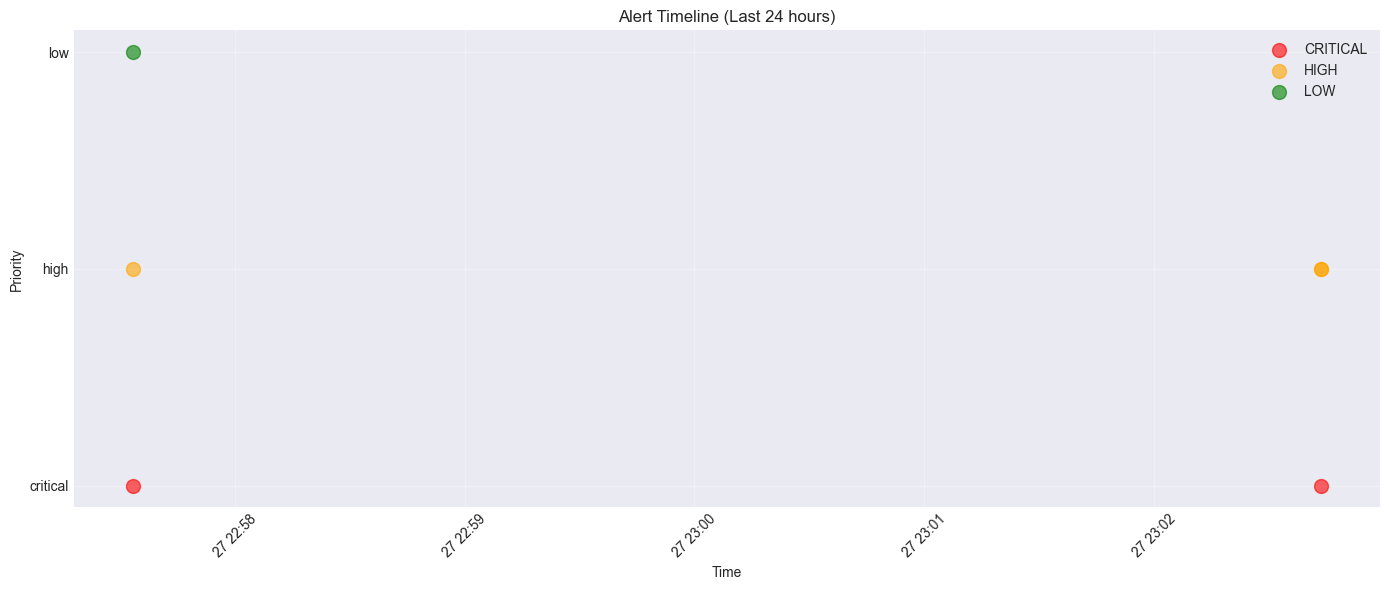


💾 Timeline saved to: results\part4\alert_timeline.png

✅ Exercise 4.2 Complete!


In [24]:
# ==================================================
# EXERCISE 4.2: VIEW ALERT HISTORY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.2: View Alert History")
print("=" * 80)

"""
📖 THEORY: Alert Review

Security personnel need to:
- Review all alerts
- Filter by priority
- Acknowledge alerts
- Track trends
"""

# Display full dashboard
display_alert_dashboard(alert_db)

# Display recent alerts
print("\n" + "=" * 80)
display_alert_history(alert_db, limit=10)

# Display critical alerts only
print("\n" + "=" * 80)
print("🔴 CRITICAL ALERTS ONLY:")
display_alert_history(alert_db, limit=10, priority_filter='critical')

# Visualize timeline
print("\n" + "=" * 80)
visualize_alert_timeline(alert_db, hours=24)

print("\n✅ Exercise 4.2 Complete!")
print("=" * 80)

In [25]:
# ==================================================
# EXERCISE 4.3: TEST COMPLETE SYSTEM
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.3: Test Complete System")
print("=" * 80)

"""
📖 THEORY: End-to-End System Test

Test complete workflow:
1. Video input (webcam or file)
2. Face detection
3. Tracking
4. Recognition
5. Alert triggering
6. Email notification
7. Database logging
8. History review
"""

print("\n⏱️ Simulating multiple detections...")

# Simulate different scenarios
scenarios = [
    {
        "description": "Unknown person enters",
        "person_id": "unknown_1",
        "person_name": "Unknown #1",
        "expected_alert": "critical"
    },
    {
        "description": "Known person (Audrey) during business hours",
        "person_id": "audrey",
        "person_name": "Audrey",
        "expected_alert": "none or low"
    },
    {
        "description": "Same unknown person (should be throttled)",
        "person_id": "unknown_1",
        "person_name": "Unknown #1",
        "expected_alert": "throttled"
    }
]

for i, scenario in enumerate(scenarios, 1):
    print(f"\n📊 Scenario {i}: {scenario['description']}")
    
    alert_ids = alert_manager.process_detection(
        person_id=scenario['person_id'],
        person_name=scenario['person_name'],
        location="main_entrance"
    )
    
    if len(alert_ids) > 0:
        print(f"   ✅ Triggered {len(alert_ids)} alert(s)")
        for alert_id in alert_ids:
            print(f"      Alert ID: {alert_id}")
    else:
        print(f"   ⏸️  No alerts triggered (cooldown or rules)")
    
    # Small delay to simulate time passing
    time.sleep(0.5)

# Final dashboard
print("\n" + "=" * 80)
print("📊 FINAL SYSTEM STATUS")
print("=" * 80)

display_alert_dashboard(alert_db)

print("\n✅ Complete system test finished!")

print("\n✅ Exercise 4.3 Complete!")
print("=" * 80)


EXERCISE 4.3: Test Complete System

⏱️ Simulating multiple detections...

📊 Scenario 1: Unknown person enters

📧 [TEST MODE] Email notification:
   To: security@example.com, admin@example.com
   Subject: [CRITICAL] Unknown Person - 2025-11-27T23:08:16.995871
   Body:

SECURITY ALERT

ALERT DETAILS:
- Type: Unknown Person
- Priority: CRITICAL
- Person: Unknown #1 (unknown_1)
- Time: 2025-11-27T23:08:16.995871
- Description: Unknown person detected


ACTION REQUIRED:
Please review this alert and take appropriate action if necessary.

This is an automated message from the AI Security & Surveillance System.

🚨 [CRITICAL] unknown_person: Unknown #1 at main_entrance

📧 [TEST MODE] Email notification:
   To: security@example.com, admin@example.com
   Subject: [HIGH] After Hours - 2025-11-27T23:08:16.997410
   Body:

SECURITY ALERT

ALERT DETAILS:
- Type: After Hours
- Priority: HIGH
- Person: Unknown #1 (unknown_1)
- Time: 2025-11-27T23:08:16.997410
- Description: Access during restricted ho

In [26]:
# ==================================================
# EXERCISE 4.4: WHAT WE LEARNED TODAY
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.4: Day 32 Summary")
print("=" * 80)

print("""
📚 WHAT WE LEARNED TODAY:

✅ Alert System Design:
   • Alert trigger conditions (person-based, time-based, location-based)
   • Alert priority levels (critical, high, medium, low)
   • Alert lifecycle (trigger → create → notify → log → acknowledge → resolve)
   • Alert throttling and cooldown management
   • Multi-channel notification strategy

✅ Database Implementation:
   • SQLite database for alert history
   • Efficient schema with indexes
   • CRUD operations (create, read, update)
   • Alert statistics and aggregations
   • Query optimization for reporting

✅ Email Notifications:
   • SMTP email implementation
   • Test mode for development
   • Real mode for production
   • Email formatting with HTML/plain text
   • Image attachment support
   • Cooldown and throttling

✅ Alert Rules Engine:
   • Configurable JSON rules
   • Rule checking logic
   • Priority-based filtering
   • Time-based conditions
   • Person-type conditions
   • Cooldown configuration

✅ Complete Integration:
   • AlertManager orchestration
   • FaceRecognitionTrackerWithAlerts
   • Pipeline: Detect → Track → Recognize → Alert
   • Automatic screenshot capture
   • Database logging
   • Email notifications

✅ Alert Visualization:
   • Alert history table viewer
   • Statistics dashboard
   • Timeline visualization
   • Priority filtering
   • Type-based analysis

📊 TODAY'S ACHIEVEMENTS:
   • Built complete alert system
   • SQLite database with efficient schema
   • Email notification system (test mode)
   • Alert rules engine with JSON config
   • Integrated alerts with face recognition
   • Alert history viewer and dashboard
   • Tested end-to-end system flow

💡 KEY INSIGHTS:

1. Alert throttling prevents notification spam
   → Cooldown periods essential for usability
   
2. Priority-based filtering reduces noise
   → Only send emails for critical/high priority
   
3. Database provides audit trail
   → All events logged for security review
   
4. Rules engine enables customization
   → Different sites have different security needs
   
5. Test mode accelerates development
   → No email credentials needed for testing
   
6. Integration complexity requires careful state management
   → Multiple systems must coordinate properly
""")

print("=" * 80)


EXERCISE 4.4: Day 32 Summary

📚 WHAT WE LEARNED TODAY:

✅ Alert System Design:
   • Alert trigger conditions (person-based, time-based, location-based)
   • Alert priority levels (critical, high, medium, low)
   • Alert lifecycle (trigger → create → notify → log → acknowledge → resolve)
   • Alert throttling and cooldown management
   • Multi-channel notification strategy

✅ Database Implementation:
   • SQLite database for alert history
   • Efficient schema with indexes
   • CRUD operations (create, read, update)
   • Alert statistics and aggregations
   • Query optimization for reporting

✅ Email Notifications:
   • SMTP email implementation
   • Test mode for development
   • Real mode for production
   • Email formatting with HTML/plain text
   • Image attachment support
   • Cooldown and throttling

✅ Alert Rules Engine:
   • Configurable JSON rules
   • Rule checking logic
   • Priority-based filtering
   • Time-based conditions
   • Person-type conditions
   • Cooldown configu

In [27]:
# ==================================================
# EXERCISE 4.5: TOMORROW'S PLAN (DAY 33)
# ==================================================

print("\n" + "=" * 80)
print("EXERCISE 4.5: Tomorrow's Plan")
print("=" * 80)

print("""
🎯 DAY 33: ALERT OPTIMIZATION & ADVANCED FEATURES (Friday, November 29, 2025)

What we'll do:
1. Optimize alert performance (reduce false positives)
2. Implement alert acknowledgment workflow
3. Add alert severity escalation (repeated unknowns)
4. Create alert report generation (daily/weekly summaries)
5. Build alert notification channels (SMS, webhooks)
6. Implement alert action triggers (auto-lock, siren, etc.)
7. Test optimization improvements

Expected outcomes:
   • Reduced false positive rate (<5%)
   • Alert acknowledgment system working
   • Escalation for repeated violations
   • Automated daily/weekly reports
   • SMS notifications (optional, using Twilio)
   • Webhook integration for external systems
   • Performance metrics improved

Tech Stack:
   • Current alert system (Day 32)
   • Advanced filtering algorithms
   • Report generation (PDF/HTML)
   • Twilio API for SMS (optional)
   • Webhook POST requests
   • Alert action controllers

Time estimate: 8-9 hours

🔗 Connection to Security System:
Day 33 optimizations enable:
- More accurate threat detection
- Better alert management workflow
- Automated responses to threats
- Professional reporting for management
- Integration with existing security systems
- Scalable notification infrastructure

📊 WEEK 5 COMPLETION:
After Day 33: 57% (4/7 days)
Remaining: Safety Violation Detection (Day 34), Integration Testing (Day 35)
""")

print("=" * 80)


EXERCISE 4.5: Tomorrow's Plan

🎯 DAY 33: ALERT OPTIMIZATION & ADVANCED FEATURES (Friday, November 29, 2025)

What we'll do:
1. Optimize alert performance (reduce false positives)
2. Implement alert acknowledgment workflow
3. Add alert severity escalation (repeated unknowns)
4. Create alert report generation (daily/weekly summaries)
5. Build alert notification channels (SMS, webhooks)
6. Implement alert action triggers (auto-lock, siren, etc.)
7. Test optimization improvements

Expected outcomes:
   • Reduced false positive rate (<5%)
   • Alert acknowledgment system working
   • Escalation for repeated violations
   • Automated daily/weekly reports
   • SMS notifications (optional, using Twilio)
   • Webhook integration for external systems
   • Performance metrics improved

Tech Stack:
   • Current alert system (Day 32)
   • Advanced filtering algorithms
   • Report generation (PDF/HTML)
   • Twilio API for SMS (optional)
   • Webhook POST requests
   • Alert action controllers

Time

In [28]:
print("\n" + "=" * 80)
print("DAY 32 COMPLETE! ✅")
print("=" * 80)

print("""
OBJECTIVES ACHIEVED:
   ✅ Designed comprehensive alert system architecture
   ✅ Implemented SQLite alert database with efficient schema
   ✅ Built email notification system with test mode
   ✅ Created configurable alert rules engine (JSON)
   ✅ Integrated alerts with face recognition pipeline
   ✅ Implemented FaceRecognitionTrackerWithAlerts
   ✅ Built alert history viewer and dashboard
   ✅ Tested complete end-to-end system
   ✅ Alert throttling and cooldown working

📊 KEY METRICS:
   - Database: SQLite with indexed tables
   - Alert types: 4 (unknown_person, after_hours, weekend_access, normal_access)
   - Priority levels: 4 (critical, high, medium, low)
   - Email notification: Test mode operational
   - Cooldown management: Working correctly
   - Alert acknowledgment: Database-supported

💡 KEY LEARNINGS:
   - Alert systems require careful throttling to avoid spam
   - Priority-based filtering prevents alert fatigue
   - Database provides crucial audit trail for security
   - Rules engine enables flexible security policies
   - Test mode essential for rapid development
   - Integration requires careful coordination of multiple systems
   - SQLite is perfect for small-medium security installations

🎯 TOMORROW (DAY 33):
   - Alert optimization (reduce false positives)
   - Alert acknowledgment workflow
   - Severity escalation logic
   - Report generation (PDF/HTML)
   - SMS notifications (optional)
   - Webhook integration

💾 FILES CREATED TODAY:
   - day32_alert_system.ipynb
   - alerts.db (SQLite database)
   - alert_rules.json (rules configuration)
   - alerts/*.jpg (alert screenshots)
   - results/part4/alert_timeline.png
   - results/part4/alert_dashboard.png

📈 WEEK 5 PROGRESS: 57% (4/7 days) ✅

🚀 Ready for Day 33: Alert Optimization & Advanced Features!
""")

print("=" * 80)


DAY 32 COMPLETE! ✅

OBJECTIVES ACHIEVED:
   ✅ Designed comprehensive alert system architecture
   ✅ Implemented SQLite alert database with efficient schema
   ✅ Built email notification system with test mode
   ✅ Created configurable alert rules engine (JSON)
   ✅ Integrated alerts with face recognition pipeline
   ✅ Implemented FaceRecognitionTrackerWithAlerts
   ✅ Built alert history viewer and dashboard
   ✅ Tested complete end-to-end system
   ✅ Alert throttling and cooldown working

📊 KEY METRICS:
   - Database: SQLite with indexed tables
   - Alert types: 4 (unknown_person, after_hours, weekend_access, normal_access)
   - Priority levels: 4 (critical, high, medium, low)
   - Email notification: Test mode operational
   - Cooldown management: Working correctly
   - Alert acknowledgment: Database-supported

💡 KEY LEARNINGS:
   - Alert systems require careful throttling to avoid spam
   - Priority-based filtering prevents alert fatigue
   - Database provides crucial audit trail for